In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno

plt.style.use("ggplot")
sns.set_palette("deep")

In [ ]:
df = pd.read_csv("/Users/prerana/Documents/Banking_case/Banking_clean.csv")

In [57]:
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,BRId,GenderId,IAId,Product_Count,Total_Financial_Value,Customer_Value,Value_Segment,Recency_Years,Frequency,Monetary
0,IND81288,Raymond Mills,24,34324,2019-06-05,Anthony Torres,American,Safety Technician IV,High,Jade,...,1,1,1,7,4637425.11,4712809.88,High Value,6.978082,7,75384.77
1,IND65833,Julia Spencer,23,42205,2001-10-12,Jonathan Hawkins,African,Software Consultant,High,Jade,...,2,1,2,7,4565342.08,4855176.39,High Value,24.635616,7,289834.31
2,IND47499,Stephen Murray,27,7314,NaT,Anthony Berry,European,Help Desk Operator,High,Gold,...,3,2,3,7,3611881.73,3781816.96,High Value,NaN,7,169935.23
3,IND72498,Virginia Garza,40,34594,NaT,Steve Diaz,American,Geologist II,Mid,Silver,...,4,1,4,7,3663584.15,4020392.26,High Value,NaN,7,356808.11
4,IND60181,Melissa Sanders,46,41269,NaT,Shawn Long,American,Assistant Professor,Mid,Platinum,...,1,2,5,7,3863582.04,3994293.72,High Value,NaN,7,130711.68


In [58]:
print("Rows, Columns:", df.shape)

Rows, Columns: (3000, 32)


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               1190 non-null   datetime64[ns]
 5   Banking Contact           3000 non-null   object        
 6   Nationality               3000 non-null   object        
 7   Occupation                3000 non-null   object        
 8   Fee Structure             3000 non-null   object        
 9   Loyalty Classification    3000 non-null   object        
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Car

In [60]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Missing values summary
df.isnull().sum()


Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

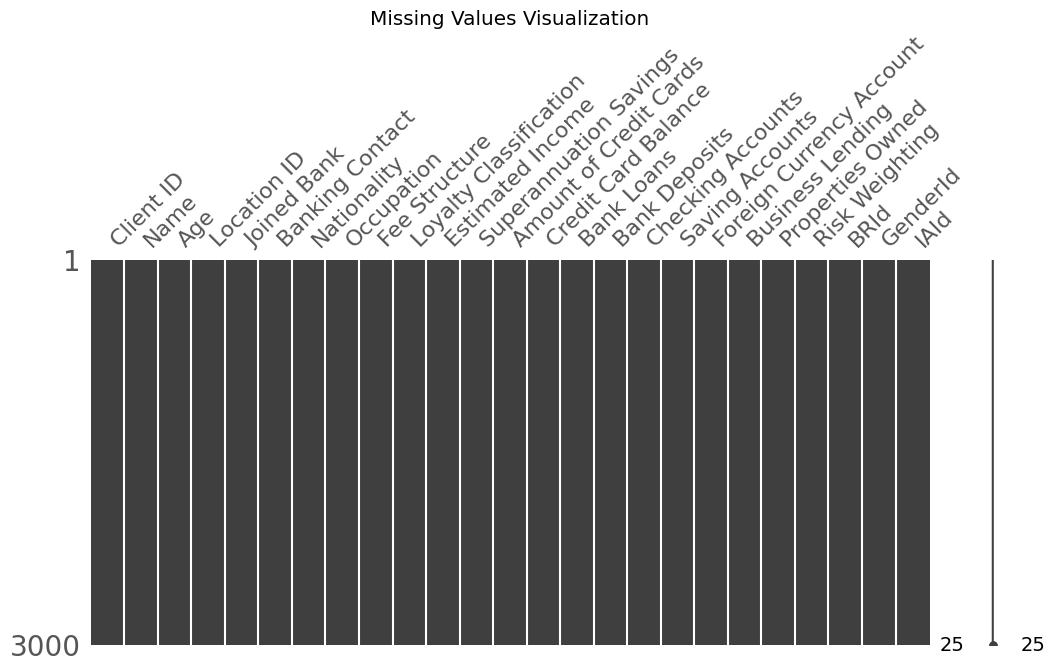

In [12]:
# Visual missing data matrix
msno.matrix(df, figsize=(12, 5))
plt.title("Missing Values Visualization")
plt.show()

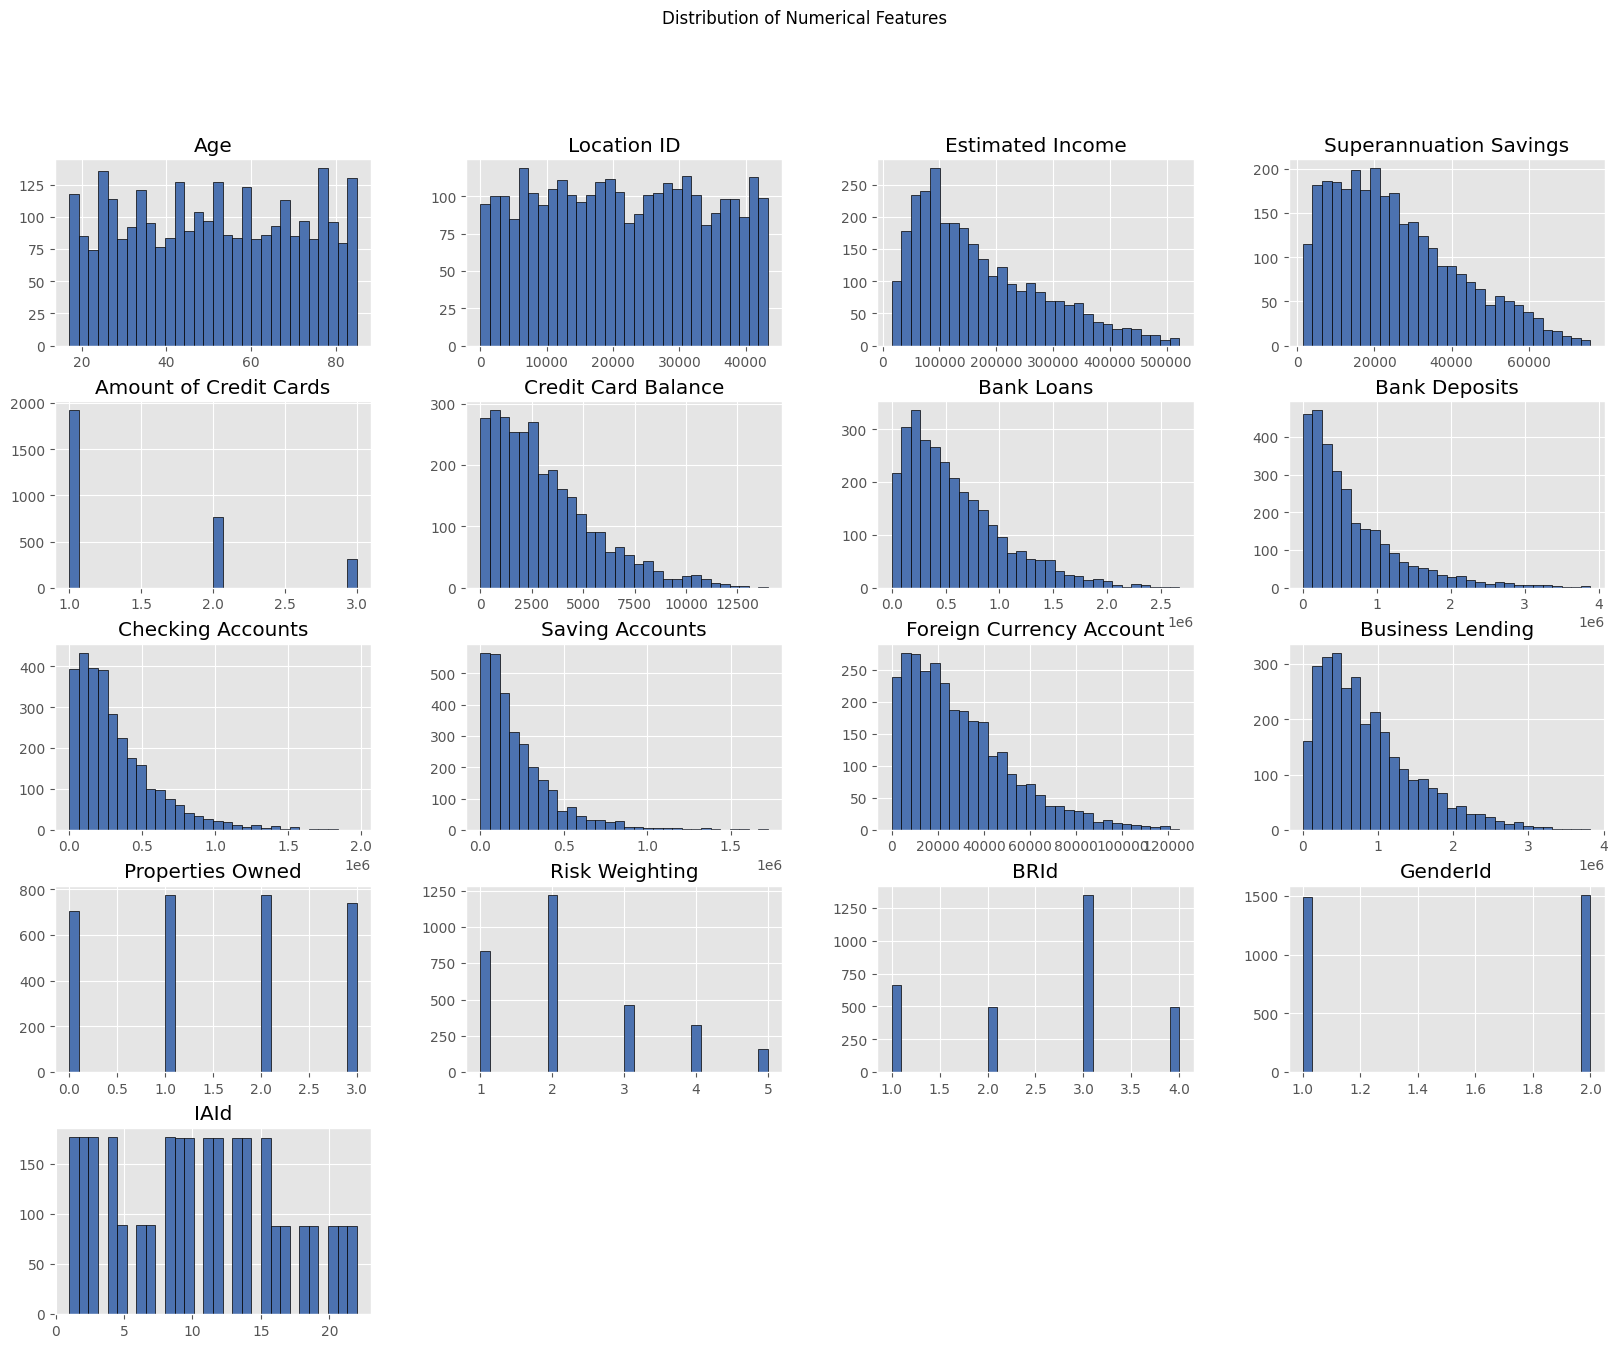

In [31]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.show()


Skipping Client ID (2940 unique values)
Skipping Name (2913 unique values)
Skipping Joined Bank (2579 unique values)
Skipping Banking Contact (49 unique values)


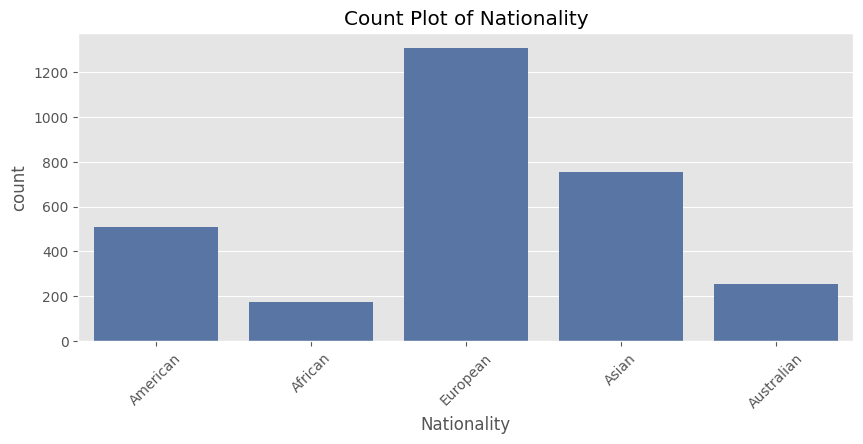

Skipping Occupation (195 unique values)


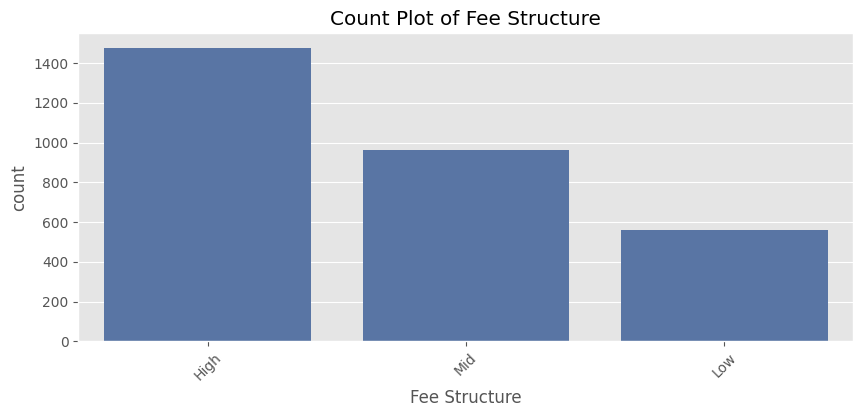

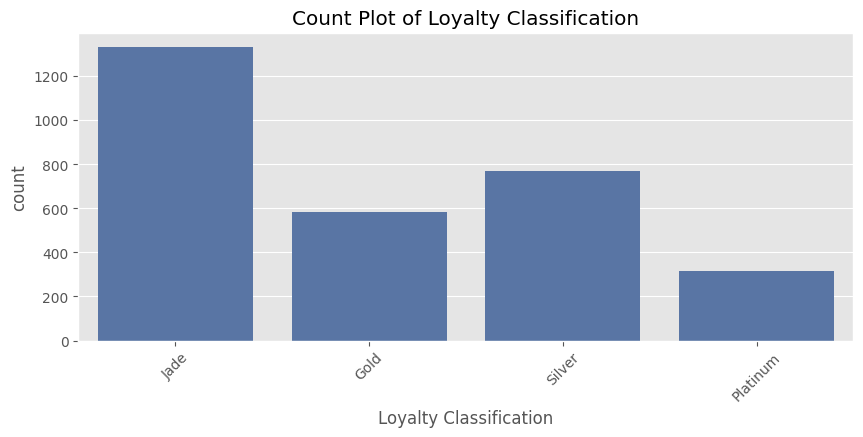

In [29]:
#Categorical Analysis
#High-cardinality categorical columns such as Client ID, Name, Joined Bank, and Banking Contact were skipped during visualization because they contain too many unique values, which makes countplot analysis uninformative.
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    unique_vals = df[col].nunique()

    # Skip very large categorical columns
    if unique_vals > 20:
        print(f"Skipping {col} ({unique_vals} unique values)")
        continue

    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

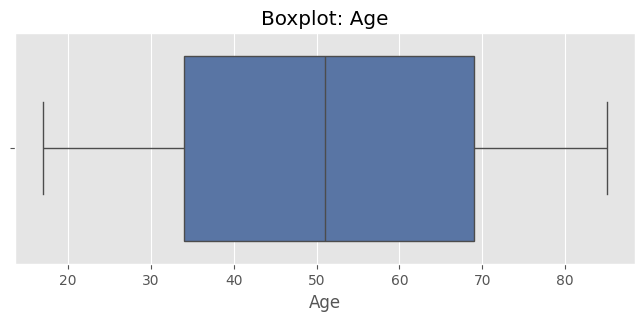

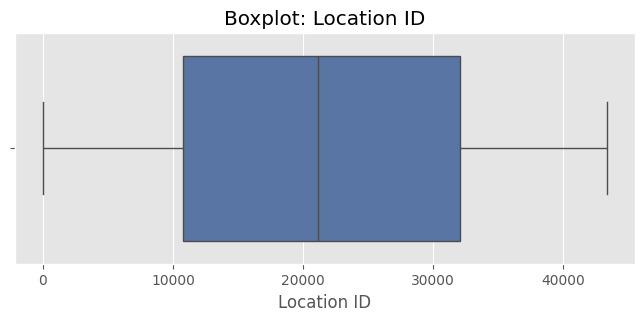

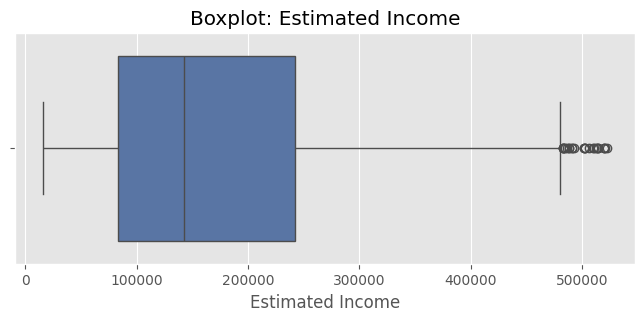

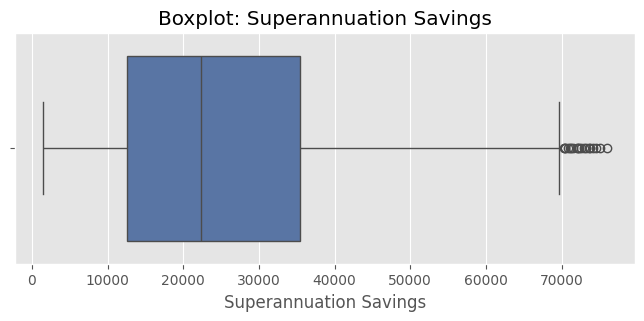

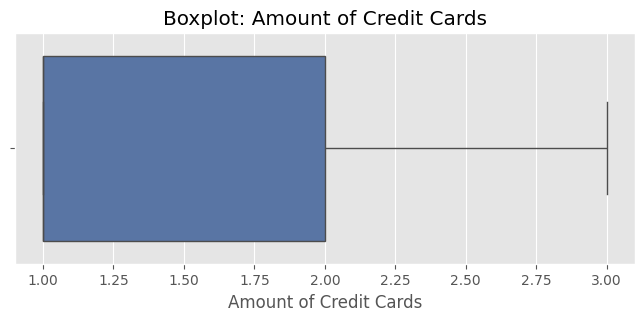

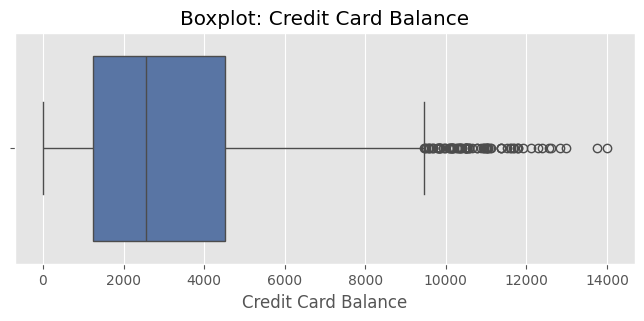

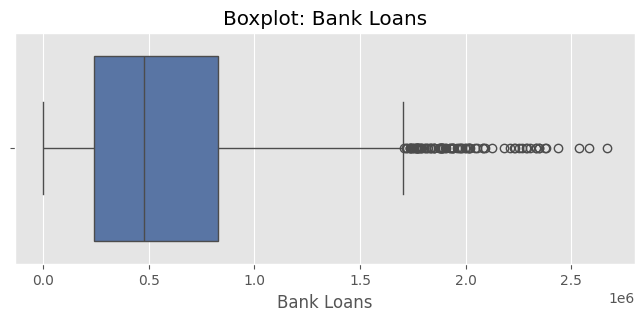

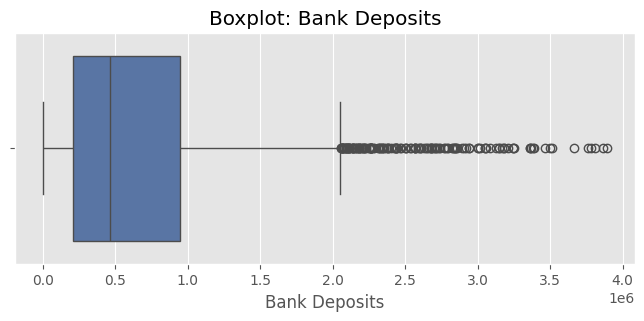

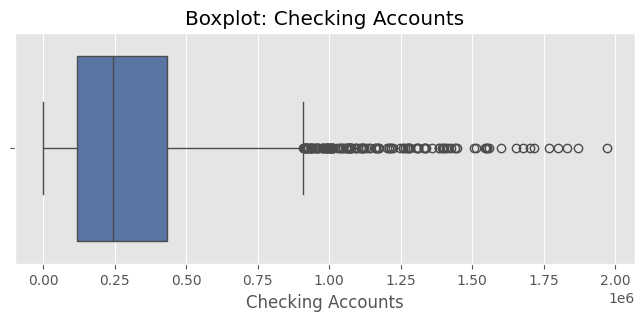

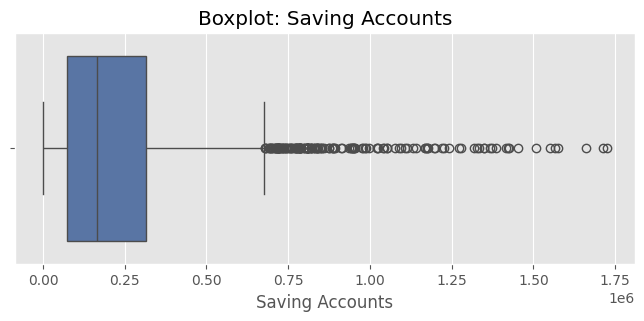

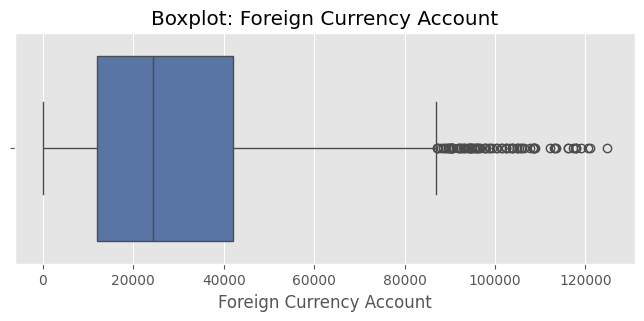

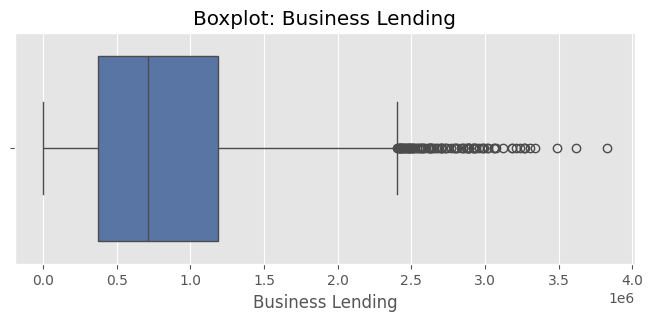

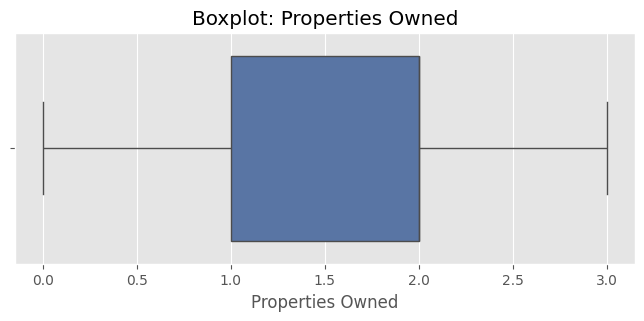

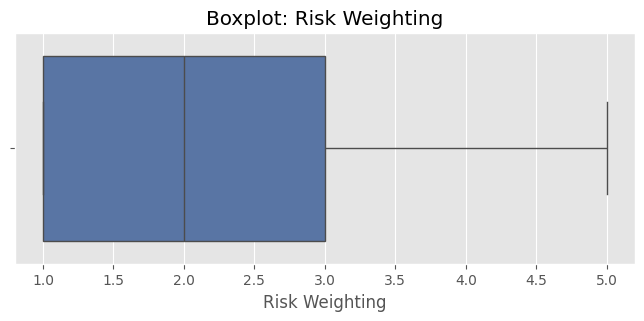

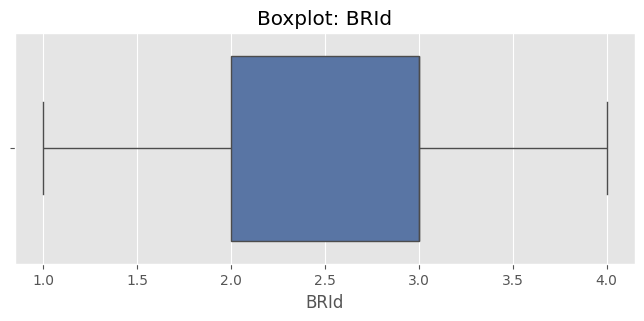

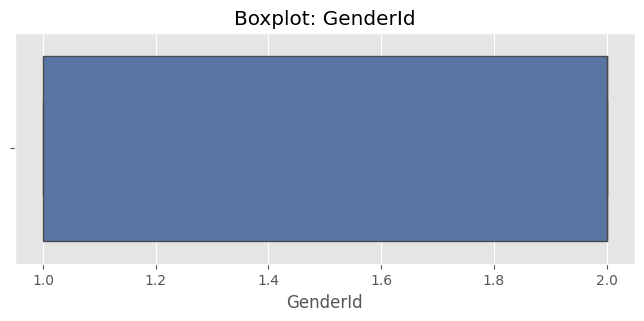

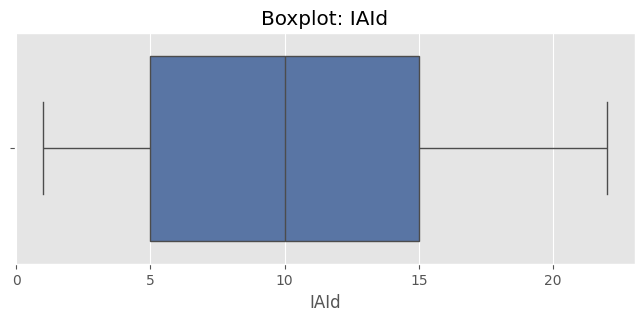

In [32]:
#Outlier detection - box plots
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

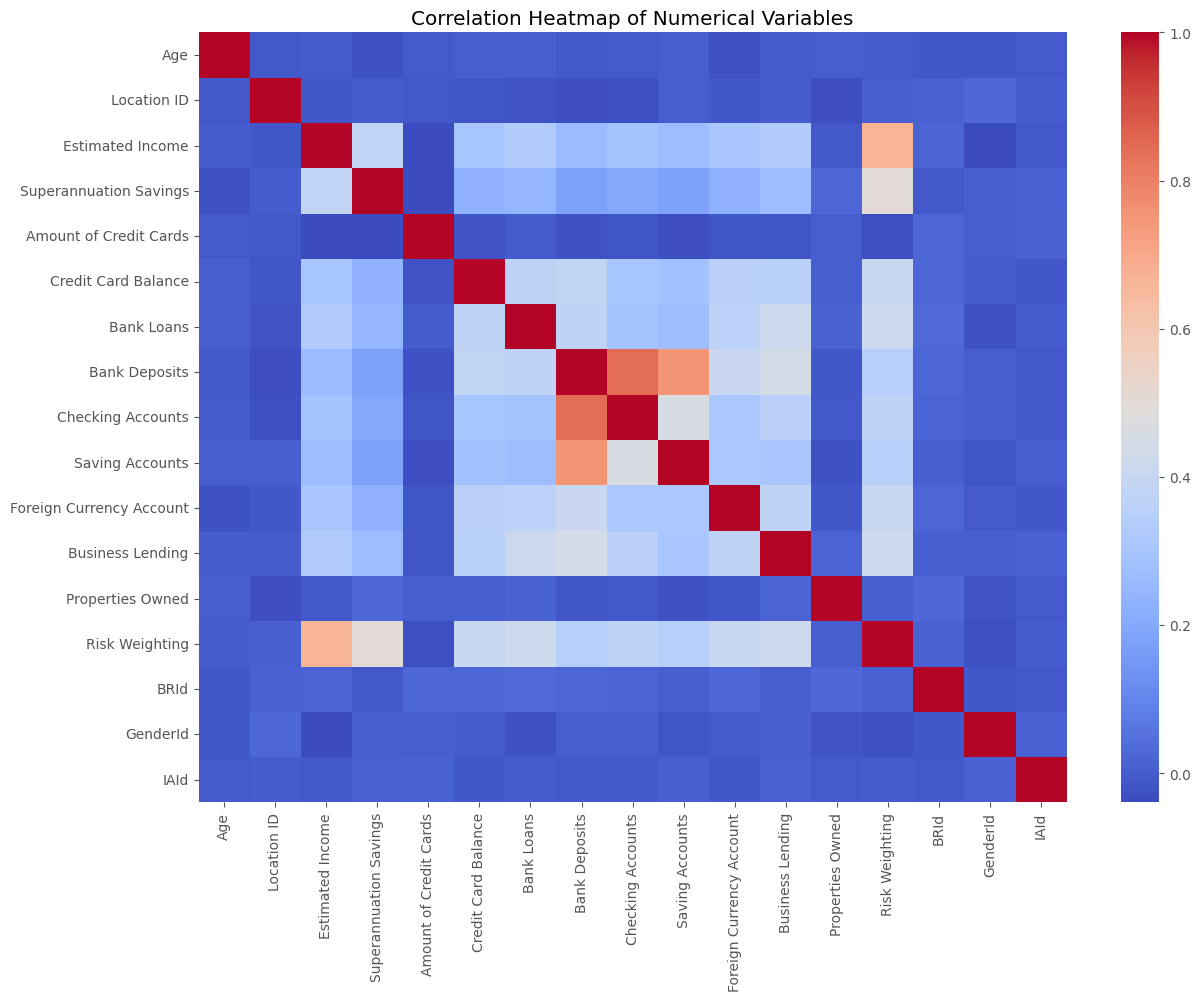

In [33]:
#Correlation Analysis
plt.figure(figsize=(14,10))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()



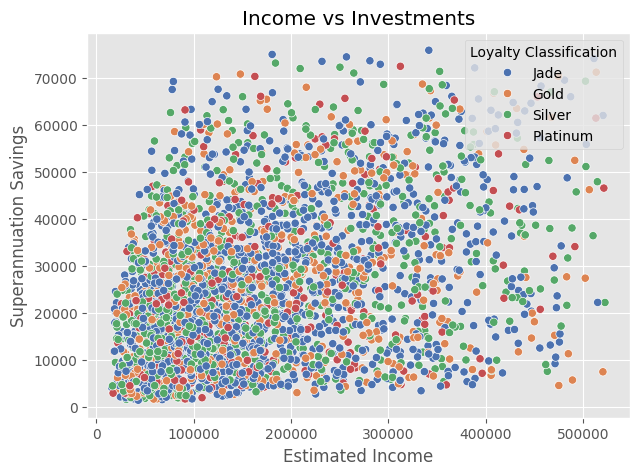

In [38]:
#Key Relationship (Bivariate Analysis): 
#1) Income vs Investments

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Estimated Income", y="Superannuation Savings", hue="Loyalty Classification")
plt.title("Income vs Investments")
plt.show()

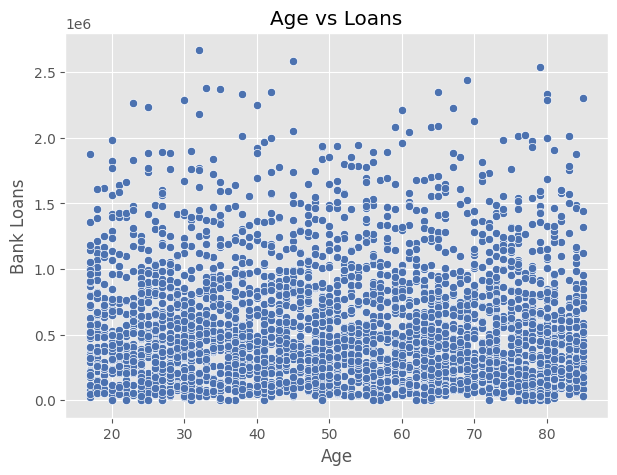

In [41]:
#2) Age vs Loans
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Age", y="Bank Loans")
plt.title("Age vs Loans")
plt.show()

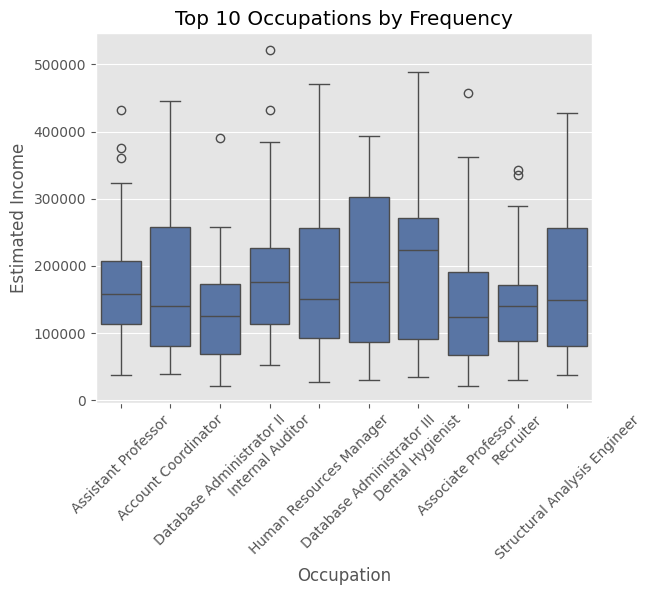

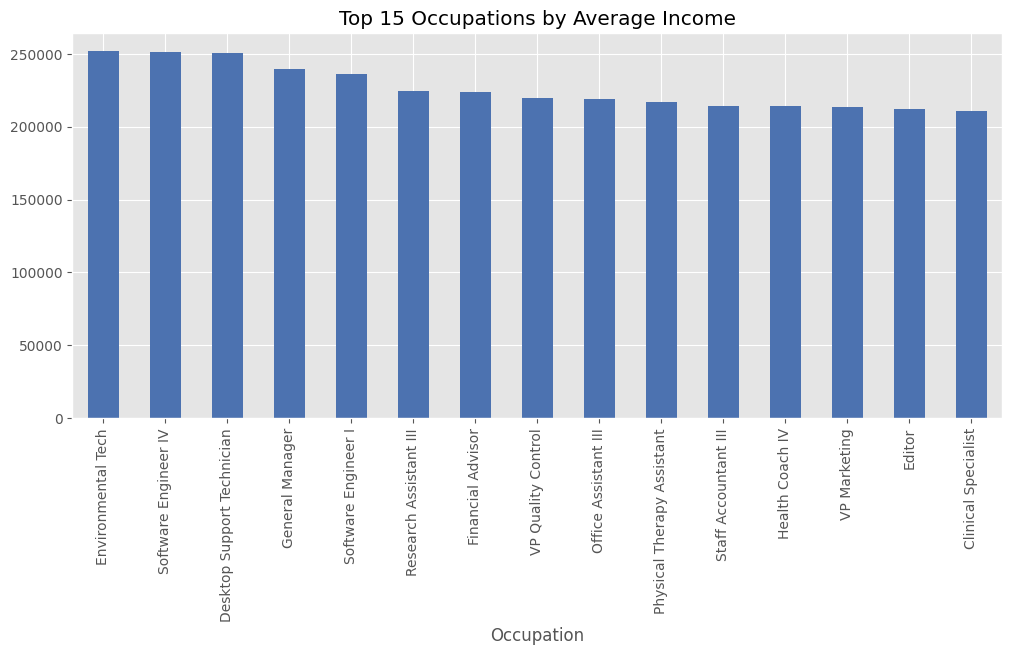

In [48]:
#3) Occupation vs Income
top10 = df['Occupation'].value_counts().head(10).index

sns.boxplot(
    data=df[df['Occupation'].isin(top10)],
    x="Occupation",
    y="Estimated Income"
)
plt.xticks(rotation=45)
plt.title("Top 10 Occupations by Frequency")
plt.show()

income_by_occ = df.groupby("Occupation")["Estimated Income"].mean().sort_values(ascending=False).head(15)

income_by_occ.plot(kind="bar", figsize=(12,5))
plt.title("Top 15 Occupations by Average Income")
plt.show()

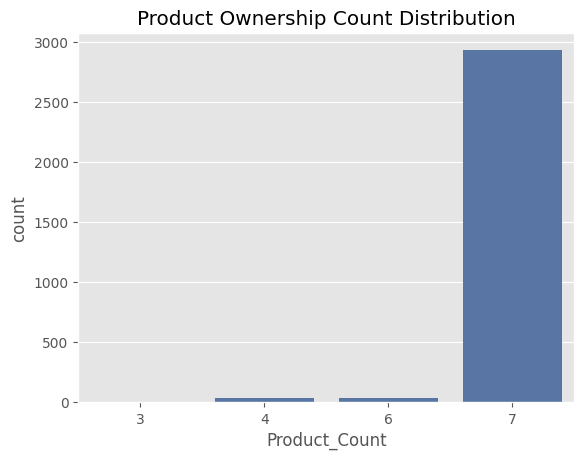

In [52]:
#Product Penetration Analysis
product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Business Lending",
    "Foreign Currency Account",
    "Saving Accounts",
    "Checking Accounts"
]

df["Product_Count"] = df[product_cols].apply(lambda x: x.gt(0).sum(), axis=1)

sns.countplot(data=df, x="Product_Count")
plt.title("Product Ownership Count Distribution")
plt.show()

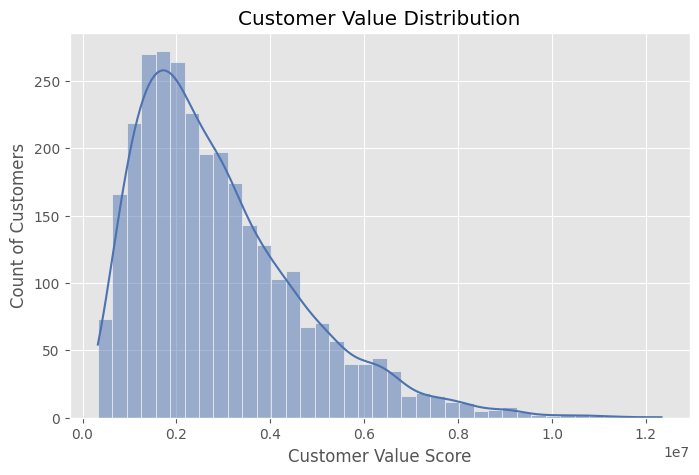

In [55]:
#Customer Value Distribution

# Total financial assets a customer holds
df["Total_Financial_Value"] = (
    df["Superannuation Savings"] +
    df["Bank Deposits"] +
    df["Saving Accounts"] +
    df["Checking Accounts"] +
    df["Foreign Currency Account"] +
    df["Business Lending"] +
    df["Bank Loans"]
)

# Combine income + assets into one value metric
df["Customer_Value"] = df["Estimated Income"] + df["Total_Financial_Value"]

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Customer_Value"], kde=True)
plt.title("Customer Value Distribution")
plt.xlabel("Customer Value Score")
plt.ylabel("Count of Customers")
plt.show()

# Categorize customers
df["Value_Segment"] = pd.qcut(df["Customer_Value"], q=3,
                              labels=["Low Value", "Mid Value", "High Value"])

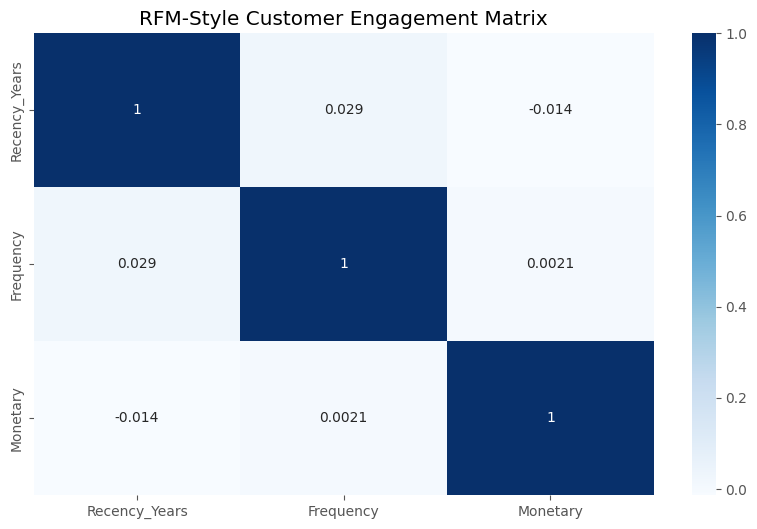

In [56]:
#RFM-Style Engagement Matrix

# Convert "Joined Bank" to datetime
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")

# Calculate recency as "years since joining"
today = pd.to_datetime("today")
df["Recency_Years"] = ((today - df["Joined Bank"]).dt.days) / 365

rfm_product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending"
]
# F: Frequency
# Count number of products actively used
df["Frequency"] = df[rfm_product_cols].gt(0).sum(axis=1)

#  M: Monetary
df["Monetary"] = df["Estimated Income"]

#RFM matrix 
rfm_matrix = df[["Recency_Years", "Frequency", "Monetary"]].copy()

# Normalize for heatmap 0–1
rfm_norm = (rfm_matrix - rfm_matrix.min()) / (rfm_matrix.max() - rfm_matrix.min())

plt.figure(figsize=(10,6))
sns.heatmap(rfm_norm.corr(), annot=True, cmap="Blues")
plt.title("RFM-Style Customer Engagement Matrix")
plt.show()

In [35]:
##Insights: 1) The strongest positive correlation occur among "Bank Deposits" with "Checking Accounts", "Saving Accounts", and Foreign Currency.
#This indicates that customers who maintain high balances in one account type often hold substantial amount/funds across other accounts as well.